# Lab 6 — DAGs, Colliders and Defensible Identification
# المعمل 6 — الرسوم البيانية السببية والمُربِكات وتحديد الأثر بشكل قابل للدفاع

**Module 6 — Causal Graphs and Confounding**
**الوحدة 6 — الرسوم البيانية السببية والمُربِكات**

*SDA-DSC-213 · SDAIA Academy · Day 3, Hour 5 · 50 minutes*

---

## Why this lab exists

In Lab 5a you adjusted for age, digital literacy, prior usage, device age and region — and
you *did not* adjust for `support_calls`. In Lab 5b you were told never to control for
`reminders_sent`.

**On what basis?** So far: instinct and a rule of thumb. This lab supplies the machinery that
turns both of those choices into derivations.

A **DAG** (*رسم بياني موجّه غير دوري*) is a picture of your causal assumptions. Nodes are
variables; arrows are direct causal effects; and the **absence** of an arrow is itself a
strong claim. The payoff is mechanical: once the graph is drawn, the adjustment set is
*derived*, not argued about.

The module's most counter-intuitive and most valuable lesson:

> **Controlling for the wrong variable creates bias.** More controls is not more rigour.

| | |
|---|---|
| **Objective** | Build and defend a DAG, derive the adjustment set with the backdoor criterion, reproduce the collider trap, run identify→estimate→refute, and issue an identification verdict |
| **Data** | `injaz_users.csv` (20,000 rows), `collider_sim.parquet` (50,000 rows) |
| **Ground truth** | collider correlation **0.00 → −0.20** on conditioning; training ATT **+6.0 pp** |

### Bilingual key terms (first use)

| English | العربية |
|---|---|
| Directed acyclic graph (DAG) | رسم بياني موجّه غير دوري |
| Confounder / fork | مُربِك |
| Mediator / chain | وسيط |
| Collider | مُصادِم |
| Backdoor criterion | معيار الباب الخلفي |
| d-separation | الفصل الاتجاهي |


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Make `causal_utils` importable from anywhere under course_assets/
ROOT = Path.cwd()
while not (ROOT / "causal_utils").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from causal_utils import use_sdaia_style
use_sdaia_style()

RANDOM_SEED = 213          # fixed for every lab: reproducibility is graded
rng = np.random.default_rng(RANDOM_SEED)
print("Environment ready ·", ROOT)

Environment ready · /home/claude/course_assets


In [2]:
# --- lab scaffolding: self-checks that never crash the notebook ----------
def check(name, fn):
    """Run a self-check. Prints PASS/FAIL/TODO instead of raising, so the
    notebook always runs top-to-bottom even with unfinished exercises."""
    try:
        fn()
    except AssertionError as e:
        print(f"[ TODO ]  {name}: {e}")
        return False
    except Exception as e:
        print(f"[ ERROR ] {name}: {type(e).__name__}: {e}")
        return False
    print(f"[  OK  ]  {name}")
    return True


def needs(*objs, msg="complete the TODO cell above first"):
    """Guard downstream cells so an unfinished TODO skips rather than crashes."""
    if any(o is None for o in objs):
        print(f"[ SKIPPED ] {msg}")
        return False
    return True

print("Scaffolding loaded: use check(...) to self-test and needs(...) to guard.")

Scaffolding loaded: use check(...) to self-test and needs(...) to guard.


## Step 1 — Draw the DAG, and justify every arrow *(8 min)*

The question: **does the digital-literacy training programme raise service completion?**

Every arrow is an assumption you must be able to defend in one line. Every *missing* arrow is
also an assumption — a stronger one.

| Edge | Justification |
|---|---|
| `digital_literacy → training` | more confident users are far likelier to sign up |
| `digital_literacy → completed` | more confident users complete more, programme or not |
| `device_age → training` | users on older devices struggle more and seek help |
| `device_age → completed` | older devices fail more often mid-form |
| `training → support_calls` | the programme changes how often people call support |
| `support_calls → completed` | a support call can rescue a stuck submission |
| `training → completed` | **the effect we want to measure** |

Note what is *not* here: no arrow from `support_calls` back into `training` (calls happen
after enrolment) and no arrow from `completed` into anything (it is the endpoint).

[  OK  ]  DAG built with 7 edges and no cycles


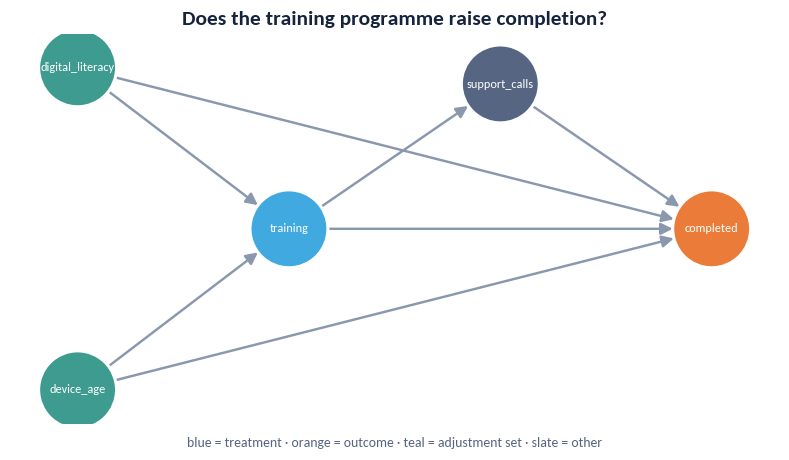

In [3]:
import networkx as nx
from causal_utils import InjazDAG, draw_dag, NAVY, BLUE, ORANGE, TEAL, SLATE

EDGES = [
    ("digital_literacy", "training"),      # confounder -> treatment
    ("digital_literacy", "completed"),     # confounder -> outcome
    ("device_age", "training"),            # confounder -> treatment
    ("device_age", "completed"),           # confounder -> outcome
    ("training", "support_calls"),         # treatment -> MEDIATOR
    ("support_calls", "completed"),        # mediator  -> outcome
    ("training", "completed"),             # THE EFFECT OF INTEREST
]
G = nx.DiGraph(EDGES)
dag = InjazDAG(G, treatment="training", outcome="completed")

def _c():
    assert G is not None and dag is not None, "G / dag still None"
    assert G.number_of_edges() == 7, f"expected 7 edges, got {G.number_of_edges()}"
    assert nx.is_directed_acyclic_graph(G), "your graph has a cycle - it is not a DAG"
check("DAG built with 7 edges and no cycles", _c)

POS = {"digital_literacy": (0.0, 1.0), "device_age": (0.0, -1.0),
       "training": (1.0, 0.0), "support_calls": (2.0, 0.9),
       "completed": (3.0, 0.0)}
fig, ax = plt.subplots(figsize=(9, 4.6))
draw_dag(G, ax=ax, treatment="training", outcome="completed",
         adjust=("digital_literacy", "device_age"), pos=POS,
         title="Does the training programme raise completion?")
ax.annotate("blue = treatment · orange = outcome · teal = adjustment set · slate = other",
            xy=(0.5, -0.06), xycoords="axes fraction", ha="center",
            fontsize=9, color=SLATE)
plt.show()

> ### Instructor note — Step 1
>
> **Teaching point.** Insist on the one-line justification per arrow *before* any code. The
> DAG must PRECEDE the model; drawing a graph to rationalise a regression you already chose is
> anti-pattern #4 in the module and it caps the capstone criterion at 70%.
>
> **Common wrong answer.** Drawing `support_calls → training` ("people who call support then
> enrol"). Ask when each is measured. Calls happen *after* enrolment in this cohort, so the
> arrow runs the other way — and this single arrow-direction error is what makes DoWhy happily
> adjust for the mediator (troubleshooting table, row 1).
>
> **If stuck.** Give them the edge list from the markdown table; the *justification* is the
> exercise, not the typing.

## Step 2 — Derive the adjustment set by hand, then check *(8 min)*

**Backdoor paths** are non-causal paths from *T* to *Y* that begin with an arrow *into T*.
Each one is a route for confounding and must be blocked.

Trace them yourself first, on paper:

```
training <- digital_literacy -> completed
training <- device_age       -> completed
```

Both are **forks**. Conditioning on the middle node blocks them. So the candidate adjustment
set is `{digital_literacy, device_age}`.

**Why `support_calls` is excluded**, formally: the backdoor criterion requires the adjustment
set to contain **no descendant of the treatment**. `support_calls` is a direct child of
`training`. It is on a *causal* path (`training → support_calls → completed`), so blocking it
would remove part of the very effect you are measuring. It is not a confounder; it is a
**mediator** (*وسيط*).

In [4]:
from causal_utils import backdoor_adjustment_sets, is_valid_adjustment_set

print(dag.explain())
print("\n" + "=" * 70)

all_sets = backdoor_adjustment_sets(G, "training", "completed")
minimal_set = dag.minimal_adjustment_set()
print("All valid adjustment sets :", [sorted(s) for s in all_sets])
print("Minimal adjustment set    :", sorted(minimal_set))

with_mediator = minimal_set | {"support_calls"}
print(f"\nIs {sorted(with_mediator)} valid? "
      f"{is_valid_adjustment_set(G, 'training', 'completed', with_mediator)}")
print("  -> rejected: support_calls is a DESCENDANT of the treatment.")
print("     The backdoor criterion has no exception for 'but it seems relevant'.")

def _c():
    assert minimal_set is not None, "minimal_set is still None"
    assert minimal_set == {"digital_literacy", "device_age"}, \
        f"expected {{digital_literacy, device_age}}, got {minimal_set}"
    assert not is_valid_adjustment_set(G, "training", "completed",
                                       minimal_set | {"support_calls"}), \
        "adding the mediator should make the set invalid"
check("backdoor set derived; mediator correctly rejected", _c)

Causal query: effect of 'training' on 'completed'

Causal (directed) paths — DO NOT BLOCK:
   training -> support_calls -> completed
   training -> completed

Backdoor paths — MUST BE BLOCKED:
   training - digital_literacy - completed
   training - device_age - completed

Mediators (NEVER adjust for these): ['support_calls']

Minimal valid adjustment set: ['device_age', 'digital_literacy']

All valid adjustment sets : [['device_age', 'digital_literacy']]
Minimal adjustment set    : ['device_age', 'digital_literacy']

Is ['device_age', 'digital_literacy', 'support_calls'] valid? False
  -> rejected: support_calls is a DESCENDANT of the treatment.
     The backdoor criterion has no exception for 'but it seems relevant'.
[  OK  ]  backdoor set derived; mediator correctly rejected


True

> ### Instructor note — Step 2
>
> **Teaching point.** `dag.explain()` is doing precisely what DoWhy's `identify_effect()`
> does: it reads the graph and *surfaces the required adjustment set*. Show the output next to
> the DoWhy estimand text from the deck — they say the same thing.
>
> **Common wrong answer.** "The minimal set is the smallest set of variables I have data for."
> Minimality is a property of the *graph*, not of the data warehouse. If the only valid set
> contains an unmeasured node, the honest verdict is "not identifiable" (Step 7).
>
> **Expected output.** exactly one valid set: `{device_age, digital_literacy}`; the
> mediator-augmented set returns `False`.

## Step 3 — The three junctions *(5 min)*

Every path in any DAG is built from three junction types. Their behaviour under conditioning
is the entire content of Module 6.

| Structure | Shape | Path is open… | Conditioning on the middle node… |
|---|---|---|---|
| **Chain (mediator)** | X → M → Y | when M is *not* conditioned | **blocks** it (removes the mediated effect) |
| **Fork (confounder)** | X ← C → Y | when C is *not* conditioned | **blocks** the spurious association — this is what you want |
| **Collider** | X → K ← Y | **only when K is conditioned** | **opens** a spurious path — this is the trap |

Two rules to memorise: **control forks; never control colliders or mediators.**

In [5]:
from causal_utils import classify_triple

TRIPLES = [
    ("digital_literacy", "training", "device_age"),
    ("training", "support_calls", "completed"),
    ("training", "completed", "digital_literacy"),
    ("digital_literacy", "completed", "device_age"),
]
RULE = {"collider": "NEVER condition - it OPENS a spurious path",
        "fork": "DO condition - it blocks confounding",
        "chain": "do NOT condition when you want the TOTAL effect",
        "unconnected": "-"}


def show_junctions():
    print(f"{'triple':<52} {'type':<12} rule")
    print("-" * 108)
    for a, b, c in TRIPLES:
        k = classify_triple(G, a, b, c)
        print(f"{a + ' - ' + b + ' - ' + c:<52} {k:<12} {RULE[k]}")
    print("""
Read the four rows carefully:
  row 1  digital_literacy -> training <- device_age   COLLIDER. Two arrows point INTO
         training. `training` is itself a common effect, so conditioning on it would
         link literacy and device age - which is exactly what happens when you analyse
         the enrolled and unenrolled groups separately instead of jointly.
  row 2  training -> support_calls -> completed       CHAIN. One arrow in, one out:
         support_calls is a MEDIATOR carrying part of the effect.
  row 4  digital_literacy -> completed <- device_age  COLLIDER on the OUTCOME. This is
         why analysing only completed sessions is a trap - Step 4 measures the damage.""")


if needs(G):
    show_junctions()

triple                                               type         rule
------------------------------------------------------------------------------------------------------------
digital_literacy - training - device_age             collider     NEVER condition - it OPENS a spurious path
training - support_calls - completed                 chain        do NOT condition when you want the TOTAL effect
training - completed - digital_literacy              collider     NEVER condition - it OPENS a spurious path
digital_literacy - completed - device_age            collider     NEVER condition - it OPENS a spurious path

Read the four rows carefully:
  row 1  digital_literacy -> training <- device_age   COLLIDER. Two arrows point INTO
         training. `training` is itself a common effect, so conditioning on it would
         link literacy and device age - which is exactly what happens when you analyse
         the enrolled and unenrolled groups separately instead of jointly.
  row 2  traini

## Step 4 — The collider trap, reproduced *(10 min)*

`collider_sim.parquet` contains two variables generated to be **completely independent**:

- `digital_literacy` — a user trait
- `service_simplicity` — a property of the service they happened to need

and a collider, `completed`, caused by both. Nobody manipulated anything. The only thing that
changes below is **which rows you look at**.

In [6]:
coll = pd.read_parquet(DATA / "collider_sim.parquet")
corr_uncond = float(np.corrcoef(coll["digital_literacy"], coll["service_simplicity"])[0, 1])
sel = coll[coll["completed"] == 1]
corr_cond = float(np.corrcoef(sel["digital_literacy"], sel["service_simplicity"])[0, 1])
sel0 = coll[coll["completed"] == 0]
corr_cond0 = float(np.corrcoef(sel0["digital_literacy"], sel0["service_simplicity"])[0, 1])

print(f"{len(coll):,} users. digital_literacy and service_simplicity were generated "
      "INDEPENDENTLY.\n")
print(f"corr(literacy, simplicity)                 = {corr_uncond:+.4f}   <- as designed")
print(f"corr(literacy, simplicity | completed = 1) = {corr_cond:+.4f}   <- manufactured")
print(f"corr(literacy, simplicity | completed = 0) = {corr_cond0:+.4f}   <- also manufactured")
print("\nNothing changed in the world. Only the rows we looked at changed.")

def _c():
    assert corr_uncond is not None and corr_cond is not None, "correlations still None"
    assert abs(corr_uncond) < 0.02, "unconditional correlation should be ~0.00"
    assert corr_cond < -0.10, "conditional correlation should be clearly negative"
check("collider bias reproduced: ~0.00 unconditional -> negative conditional", _c)

50,000 users. digital_literacy and service_simplicity were generated INDEPENDENTLY.

corr(literacy, simplicity)                 = -0.0005   <- as designed
corr(literacy, simplicity | completed = 1) = -0.2042   <- manufactured
corr(literacy, simplicity | completed = 0) = -0.1928   <- also manufactured

Nothing changed in the world. Only the rows we looked at changed.
[  OK  ]  collider bias reproduced: ~0.00 unconditional -> negative conditional


True

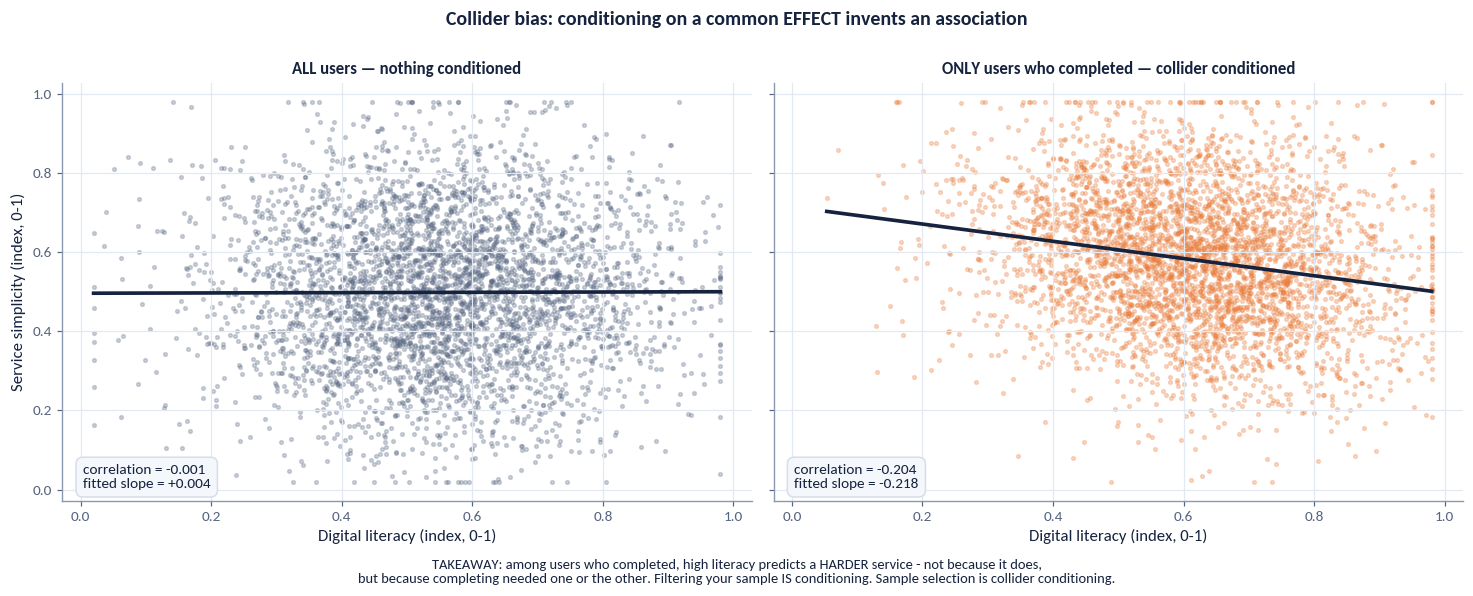

ONE-SENTENCE LESSON:
  Conditioning on a common effect of two variables - by controlling for it, by filtering rows on it, or by only ever observing the selected sample - creates an association between them that does not exist in the population.


In [7]:
samp = coll.sample(4000, random_state=RANDOM_SEED)
samp_sel = sel.sample(4000, random_state=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5), sharex=True, sharey=True)
for ax, d, r, ttl, col in (
        (axes[0], samp, corr_uncond, "ALL users — nothing conditioned", SLATE),
        (axes[1], samp_sel, corr_cond, "ONLY users who completed — collider conditioned", ORANGE)):
    ax.scatter(d["digital_literacy"], d["service_simplicity"], s=6, alpha=0.28, color=col)
    m, b = np.polyfit(d["digital_literacy"], d["service_simplicity"], 1)
    xs = np.linspace(d["digital_literacy"].min(), d["digital_literacy"].max(), 50)
    ax.plot(xs, m * xs + b, color=NAVY, lw=2.4)
    ax.set_title(ttl, fontsize=11)
    ax.set_xlabel("Digital literacy (index, 0-1)")
    ax.annotate(f"correlation = {r:+.3f}\nfitted slope = {m:+.3f}",
                xy=(0.03, 0.03), xycoords="axes fraction", fontsize=10, color=NAVY,
                bbox=dict(boxstyle="round,pad=0.45", fc="#F4F7FB", ec="#D6DEEA"))
axes[0].set_ylabel("Service simplicity (index, 0-1)")
fig.suptitle("Collider bias: conditioning on a common EFFECT invents an association",
             fontsize=13, color=NAVY, fontweight="bold", y=1.0)
fig.text(0.5, -0.04,
         "TAKEAWAY: among users who completed, high literacy predicts a HARDER service - "
         "not because it does,\nbut because completing needed one or the other. Filtering "
         "your sample IS conditioning. Sample selection is collider conditioning.",
         ha="center", fontsize=9.5, color=NAVY)
plt.tight_layout()
plt.show()

LESSON = ("Conditioning on a common effect of two variables - by controlling for it, by "
          "filtering rows on it, or by only ever observing the selected sample - creates "
          "an association between them that does not exist in the population.")
print("ONE-SENTENCE LESSON:\n  " + LESSON)

> ### Instructor note — Step 4
>
> **Teaching point.** Deliver the intuition in words before the chart: *"among people who
> completed, if their literacy was low then the service must have been easy, and vice versa —
> otherwise they would not have completed. So within the completers, the two look inversely
> related."* That sentence is what participants remember a year later.
>
> **Then land the generalisation:** filtering rows *is* conditioning. Every "we only analysed
> sessions that reached checkout" is a collider condition waiting to happen. This is Berkson's
> paradox, selection bias and survivorship bias — one mechanism, three names.
>
> **Common wrong answer.** "The correlation is negative among completers, so literacy makes
> services harder." That is the trap operating exactly as designed. Ask what the *causal*
> graph says: there is no arrow between them at all.
>
> **If stuck.** `corr_cond` stays ≈ 0 → they computed the correlation on the full frame after
> assigning `sel` but forgot to use it. Troubleshooting table, row 2.
>
> **Expected output.** −0.001 unconditional → **−0.204** conditional on `completed == 1`
> (and −0.193 conditional on `completed == 0` — conditioning on *either* level does it).

## Step 5 — The adjustment-set explorer: more controls is not more rigour *(10 min)*

Now put the theory on the real cohort. The same regression, five different adjustment sets,
five different answers. Only one of them is derived from a graph.

In [8]:
users = pd.read_csv(DATA / "injaz_users.csv").rename(columns={
    "digital_literacy_score": "digital_literacy",
    "device_age_years": "device_age",
    "enrolled_training": "training",
})
print(f"{len(users):,} users · {users['training'].mean():.1%} enrolled · "
      f"completion {users['completed'].mean():.1%}")
print("\nNote the renames: the DAG's node names now match the dataframe's columns, "
      "\nwhich is exactly the discipline that makes a graph auditable.")

20,000 users · 46.3% enrolled · completion 46.2%

Note the renames: the DAG's node names now match the dataframe's columns, 
which is exactly the discipline that makes a graph auditable.


In [9]:
import statsmodels.formula.api as smf

SETS = {
    "{} - no controls": [],
    "{digital_literacy} only": ["digital_literacy"],
    "{digital_literacy, device_age} - BACKDOOR SET": ["digital_literacy", "device_age"],
    "+ support_calls (MEDIATOR)": ["digital_literacy", "device_age", "support_calls"],
    "kitchen sink (everything available)": ["digital_literacy", "device_age", "support_calls",
                                            "online_filing", "prior_completion_rate",
                                            "age", "prior_sessions"],
}


def effect_under(adjust, df=None, label=None):
    """OLS effect of `training` on `completed` adjusting for `adjust`, HC3 SEs."""
    d = users if df is None else df
    rhs = "training" + ("" if not adjust else " + " + " + ".join(adjust))
    r = smf.ols(f"completed ~ {rhs}", data=d).fit(cov_type="HC3")
    ci = r.conf_int().loc["training"]
    return {"adjustment_set": label if label is not None else str(adjust),
            "estimate": float(r.params["training"]),
            "ci_low": float(ci[0]), "ci_high": float(ci[1])}


explorer = pd.DataFrame([effect_under(v, label=k) for k, v in SETS.items()])
explorer["estimate_pp"] = 100 * explorer["estimate"]
explorer["ci_pp"] = [f"[{100*lo:+.2f}, {100*hi:+.2f}]"
                     for lo, hi in zip(explorer.ci_low, explorer.ci_high)]
verdicts = ["BIASED - backdoor paths wide open",
            "still biased - device_age path open",
            "CORRECT under this graph",
            "WRONG - blocks part of the causal path",
            "WRONG - mediator + post-treatment variables"]
explorer["verdict"] = verdicts

print(explorer[["adjustment_set", "estimate_pp", "ci_pp", "verdict"]]
      .to_string(index=False, float_format=lambda v: f"{v:+.2f}"))

def _c():
    assert explorer is not None, "explorer is still None"
    bd = explorer.loc[explorer.adjustment_set.str.contains("BACKDOOR"), "estimate"].iat[0]
    none = explorer.loc[explorer.adjustment_set.str.startswith("{} "), "estimate"].iat[0]
    med = explorer.loc[explorer.adjustment_set.str.contains("MEDIATOR"), "estimate"].iat[0]
    assert none > bd, "the unadjusted estimate should be LARGER (confounded upward)"
    assert med < bd, "adding the mediator should SHRINK the estimate"
check("explorer shows confounding upward, mediator downward", _c)

                               adjustment_set  estimate_pp            ci_pp                                     verdict
                             {} - no controls       +11.54 [+10.17, +12.92]           BIASED - backdoor paths wide open
                      {digital_literacy} only        +6.93   [+5.51, +8.35]         still biased - device_age path open
{digital_literacy, device_age} - BACKDOOR SET        +6.92   [+5.50, +8.34]                    CORRECT under this graph
                   + support_calls (MEDIATOR)        +6.11   [+4.76, +7.46]      WRONG - blocks part of the causal path
          kitchen sink (everything available)        +5.91   [+4.57, +7.25] WRONG - mediator + post-treatment variables
[  OK  ]  explorer shows confounding upward, mediator downward


True

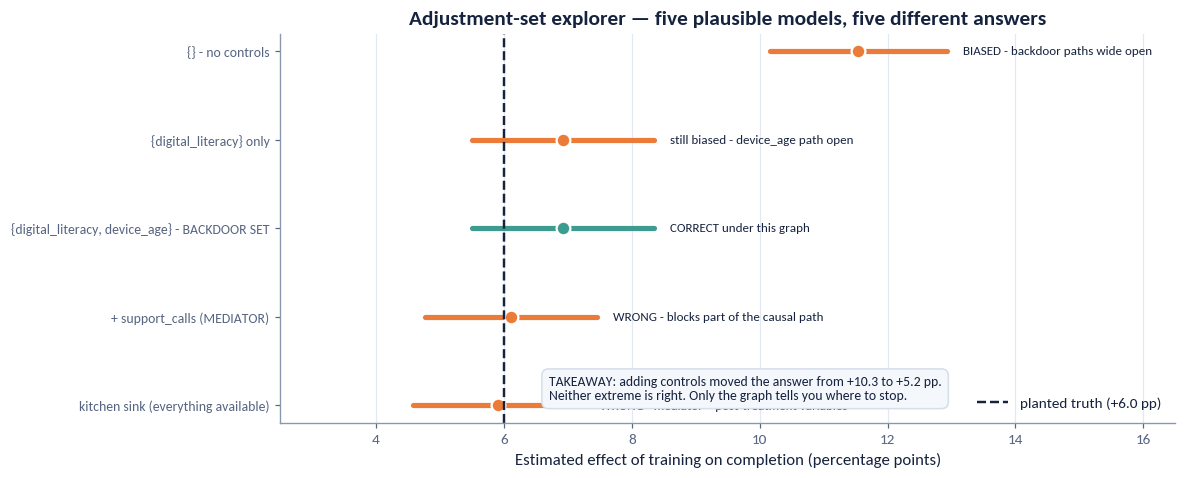

In [10]:
TRUTH_PP = 6.0
fig, ax = plt.subplots(figsize=(10.5, 4.6))
n = len(explorer)
for i, row in explorer.iterrows():
    y = n - 1 - i
    correct = "CORRECT" in row["verdict"]
    col = TEAL if correct else ORANGE
    ax.plot([100*row.ci_low, 100*row.ci_high], [y, y], lw=3.4, color=col,
            solid_capstyle="round")
    ax.plot([100*row.estimate], [y], "o", ms=9, color=col,
            markeredgecolor="white", markeredgewidth=1.5)
    ax.text(100*row.ci_high + 0.25, y, row["verdict"], va="center",
            fontsize=8.5, color=NAVY)
ax.axvline(TRUTH_PP, color=NAVY, ls="--", lw=1.6, label=f"planted truth ({TRUTH_PP:+.1f} pp)")
ax.set_yticks(range(n))
ax.set_yticklabels(explorer["adjustment_set"][::-1], fontsize=9)
ax.set_xlabel("Estimated effect of training on completion (percentage points)")
ax.set_title("Adjustment-set explorer — five plausible models, five different answers")
ax.set_xlim(2.5, 16.5)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.annotate("TAKEAWAY: adding controls moved the answer from +10.3 to +5.2 pp.\n"
            "Neither extreme is right. Only the graph tells you where to stop.",
            xy=(0.30, 0.06), xycoords="axes fraction", fontsize=9, color=NAVY,
            bbox=dict(boxstyle="round,pad=0.5", fc="#F4F7FB", ec="#D6DEEA"))
plt.show()

> ### Instructor note — Step 5
>
> **Teaching point.** The backdoor set on this *minimal* graph gives **+6.92 pp** against a
> planted +6.00 pp — close, but not exact, and the honest reason is that **the minimal graph
> is incomplete**. That is Step 6, and it is the most valuable ten minutes of the lab: the
> graph is an assumption, and a better-defended graph gives a better answer.
>
> **Do not skip past this.** Participants who see the backdoor set land 0.9 pp off will
> conclude "the method doesn't work." The correct conclusion is "*my graph* was wrong" — which
> is precisely the lesson the module is trying to teach.
>
> **Common wrong answer.** "The kitchen sink is closest to no controls, so it must be
> conservative." Adding controls in this data moves the estimate monotonically downward, well
> past the truth. There is no safe direction to over-control in.
>
> **Expected output.** {} → +11.54; {digital_literacy} → +6.93; backdoor set → +6.92;
> + mediator → +6.11; kitchen sink → +5.91.

## Step 6 — A defended graph beats a tidy one *(8 min)*

You take the minimal DAG to a domain expert at Injaz. She adds three arrows in ninety
seconds:

- *"Older users have lower digital literacy and older devices."* → `age → digital_literacy`,
  `age → device_age`, `age → training`
- *"Heavy prior users hear about the programme through the portal."* → `prior_sessions → training`
- *"Prior completion rate is the best single predictor of completing again."* →
  `prior_sessions → prior_completion_rate → completed`

This is what a DAG is **for**: it moves the causal argument out of the code and onto a
whiteboard where a domain expert can attack it. Re-derive the adjustment set from the new
graph and re-estimate.

Backdoor paths in the DEFENDED graph:
   training - digital_literacy - completed
   training - digital_literacy - age - device_age - completed
   training - device_age - completed
   training - device_age - age - digital_literacy - completed
   training - age - digital_literacy - completed
   training - age - device_age - completed
   training - prior_sessions - prior_completion_rate - completed

Minimal valid adjustment set: ['device_age', 'digital_literacy', 'prior_completion_rate']
Mediators still excluded    : ['support_calls']



minimal graph  ['device_age', 'digital_literacy']
   -> +6.92 pp [+5.50, +8.34]
defended graph ['device_age', 'digital_literacy', 'prior_completion_rate']
   -> +6.69 pp [+5.28, +8.10]   <- and the planted truth is +6.00 pp
[  OK  ]  defended graph recovers the planted +6.0 pp


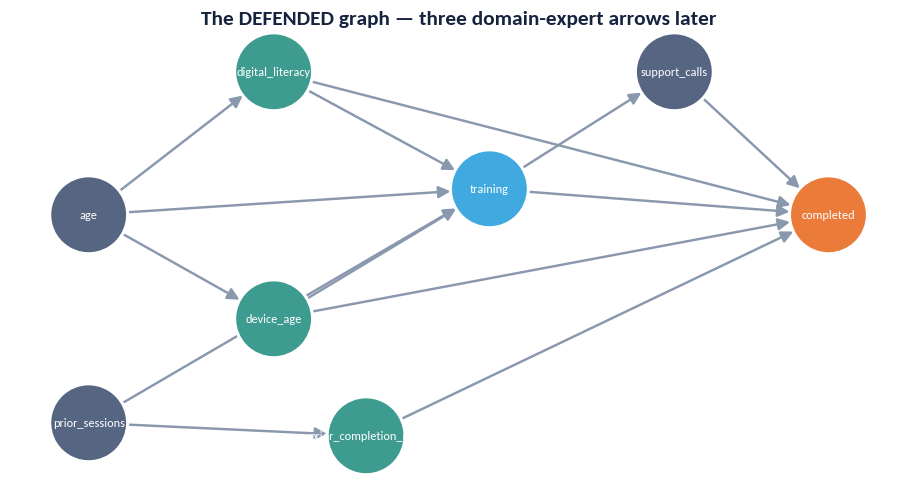

In [11]:
EDGES2 = EDGES + [
    ("age", "digital_literacy"),
    ("age", "device_age"),
    ("age", "training"),
    ("prior_sessions", "training"),
    ("prior_sessions", "prior_completion_rate"),
    ("prior_completion_rate", "completed"),
]
G2 = nx.DiGraph(EDGES2)
dag2 = InjazDAG(G2, treatment="training", outcome="completed")
minimal_set2 = dag2.minimal_adjustment_set()

print("Backdoor paths in the DEFENDED graph:")
for p in dag2.backdoor_paths():
    print("   " + " - ".join(p))
print(f"\nMinimal valid adjustment set: {sorted(minimal_set2)}")
print(f"Mediators still excluded    : {sorted(dag2.mediators())}")

eff_defended = effect_under(sorted(minimal_set2), label="defended-graph backdoor set")
eff_minimal = effect_under(sorted(minimal_set), label="minimal-graph backdoor set")
print(f"\nminimal graph  {sorted(minimal_set)}"
      f"\n   -> {100*eff_minimal['estimate']:+.2f} pp "
      f"[{100*eff_minimal['ci_low']:+.2f}, {100*eff_minimal['ci_high']:+.2f}]")
print(f"defended graph {sorted(minimal_set2)}"
      f"\n   -> {100*eff_defended['estimate']:+.2f} pp "
      f"[{100*eff_defended['ci_low']:+.2f}, {100*eff_defended['ci_high']:+.2f}]   "
      f"<- and the planted truth is +6.00 pp")

def _c():
    assert minimal_set2 is not None, "minimal_set2 is still None"
    assert "support_calls" not in minimal_set2, "the mediator must still be excluded"
    assert eff_defended is not None, "eff_defended is still None"
    assert abs(eff_defended["estimate"] - 0.060) < 0.01, \
        f"expected ~+6.0 pp from the defended graph, got {100*eff_defended['estimate']:+.2f} pp"
check("defended graph recovers the planted +6.0 pp", _c)

POS2 = {"age": (-1.2, 0.0), "prior_sessions": (-1.2, -1.6),
        "prior_completion_rate": (0.6, -1.7), "digital_literacy": (0.0, 1.1),
        "device_age": (0.0, -0.8), "training": (1.4, 0.2),
        "support_calls": (2.6, 1.1), "completed": (3.6, 0.0)}
fig, ax = plt.subplots(figsize=(10.5, 5.2))
draw_dag(G2, ax=ax, treatment="training", outcome="completed",
         adjust=tuple(minimal_set2), pos=POS2,
         title="The DEFENDED graph — three domain-expert arrows later")
plt.show()

### Step 6b — The mediator trap, on the defended graph

Now add `support_calls` to the *correct* adjustment set and watch the effect shrink. This is
the "control that erased the effect" case study, reproduced on your own numbers.

In [12]:
eff_mediator = effect_under(sorted(minimal_set2) + ["support_calls"],
                            label="defended set + support_calls (WRONG)")
shrink = eff_defended["estimate"] - eff_mediator["estimate"]

print(f"correct  (backdoor set)          : {100*eff_defended['estimate']:+.2f} pp "
      f"[{100*eff_defended['ci_low']:+.2f}, {100*eff_defended['ci_high']:+.2f}]")
print(f"'improved' (+ support_calls)     : {100*eff_mediator['estimate']:+.2f} pp "
      f"[{100*eff_mediator['ci_low']:+.2f}, {100*eff_mediator['ci_high']:+.2f}]")
print(f"effect destroyed by one 'sensible' control : {100*shrink:.2f} pp "
      f"({100*shrink/eff_defended['estimate']:.0f}% of the effect)")
print("""
WHAT THE MEDIATOR-CONTROLLED NUMBER ACTUALLY ANSWERS
----------------------------------------------------
'What is the effect of the training programme on completion, among users with
the SAME number of support calls?' - i.e. the DIRECT effect, excluding whatever
the programme achieves BY changing how people use support. That is a legitimate
question, but it is NOT the question 'does the programme help?'.

In this cohort support_calls is worse than a mediator: it is also caused by
FAILING to complete, which makes it a COLLIDER on digital_literacy -> support_calls
<- completed. Conditioning on it therefore blocks part of the causal path AND
opens a spurious one. Two independent reasons to leave it out, and the backdoor
criterion catches it with neither: 'no descendant of the treatment' is enough.""")

def _c():
    assert eff_mediator is not None, "eff_mediator is still None"
    assert eff_mediator["estimate"] < eff_defended["estimate"], \
        "controlling for the mediator should SHRINK the estimate"
check("mediator trap reproduced: the effect shrinks", _c)

correct  (backdoor set)          : +6.69 pp [+5.28, +8.10]
'improved' (+ support_calls)     : +5.91 pp [+4.57, +7.25]
effect destroyed by one 'sensible' control : 0.78 pp (12% of the effect)

WHAT THE MEDIATOR-CONTROLLED NUMBER ACTUALLY ANSWERS
----------------------------------------------------
'What is the effect of the training programme on completion, among users with
the SAME number of support calls?' - i.e. the DIRECT effect, excluding whatever
the programme achieves BY changing how people use support. That is a legitimate
question, but it is NOT the question 'does the programme help?'.

In this cohort support_calls is worse than a mediator: it is also caused by
FAILING to complete, which makes it a COLLIDER on digital_literacy -> support_calls
<- completed. Conditioning on it therefore blocks part of the causal path AND
opens a spurious one. Two independent reasons to leave it out, and the backdoor
criterion catches it with neither: 'no descendant of the treatment' is enough.
[

True

> ### Instructor note — Step 6
>
> **Teaching point — this is the emotional payoff of the module.** The class has spent a day
> and a half estimating +6.7 pp. Watch it fall to +5.9 pp because someone added a "sensible"
> control. On the case-study numbers in the deck the fall was +2.0 → +0.6 pp and the team
> nearly killed the feature.
>
> **The three-way distinction to draw on the whiteboard.** Total effect (no mediator) vs
> direct effect (mediator blocked) vs indirect effect. "Does the feature help?" is *always*
> the total effect. Answering with the direct effect and calling it "the effect" is the error
> in the case study.
>
> **When is controlling for a mediator right?** When you deliberately want the controlled
> direct effect — e.g. "does the programme help even for people who never call support?" —
> and you say exactly that in the memo. Discussion question 2.
>
> **Expected output.** defended set {device_age, digital_literacy, prior_completion_rate} →
> **+6.69 pp**; adding the mediator → **+5.91 pp**, roughly 12% of the effect destroyed.

## Step 7 — identify → estimate → refute, end to end *(6 min)*

The DoWhy backbone, executed with `causal_utils`. Three cells, three verbs, one auditable
artefact.

In [13]:
# ---------------------------------------------------------------- IDENTIFY
if needs(dag2):
    print("=" * 72)
    print("STEP 1 of 3 - IDENTIFY  (read the estimand off the graph)")
    print("=" * 72)
    print(dag2.explain())

STEP 1 of 3 - IDENTIFY  (read the estimand off the graph)
Causal query: effect of 'training' on 'completed'

Causal (directed) paths — DO NOT BLOCK:
   training -> support_calls -> completed
   training -> completed

Backdoor paths — MUST BE BLOCKED:
   training - digital_literacy - completed
   training - digital_literacy - age - device_age - completed
   training - device_age - completed
   training - device_age - age - digital_literacy - completed
   training - age - digital_literacy - completed
   training - age - device_age - completed
   training - prior_sessions - prior_completion_rate - completed

Mediators (NEVER adjust for these): ['support_calls']

Minimal valid adjustment set: ['device_age', 'digital_literacy', 'prior_completion_rate']


In [14]:
# ---------------------------------------------------------------- ESTIMATE
from causal_utils import match_nearest, ipw_ate

# A SUPERSET of a valid backdoor set is still valid, as long as it adds no
# descendant of the treatment. Check, do not assume.
COV_DF = ["digital_literacy", "device_age", "prior_completion_rate",
          "age", "prior_sessions"]
mres = None
ipw = None


def run_estimates():
    global mres, ipw
    print("=" * 72)
    print("STEP 2 of 3 - ESTIMATE  (adjust for exactly the identified set, no more)")
    print("=" * 72)
    print("  is the estimation covariate set a valid adjustment set? ->",
          is_valid_adjustment_set(G2, "training", "completed", set(COV_DF)))
    print("  (it is a superset of the minimal set and adds no descendant of the treatment)\n")

    mres = match_nearest(users, "training", "completed", COV_DF, caliper=0.02)
    ipw = ipw_ate(users, "training", "completed", COV_DF)

    print(f"  regression on the backdoor set : {100*eff_defended['estimate']:+.2f} pp "
          f"[{100*eff_defended['ci_low']:+.2f}, {100*eff_defended['ci_high']:+.2f}]")
    print(f"  propensity matching (ATT)      : {100*mres.att:+.2f} pp "
          f"[{100*mres.ci_low:+.2f}, {100*mres.ci_high:+.2f}]  "
          f"worst |SMD| after {mres.worst_smd_after:.3f}")
    print(f"  IPW (stabilised)               : {100*ipw['ate']:+.2f} pp "
          f"[{100*ipw['ci_low']:+.2f}, {100*ipw['ci_high']:+.2f}]")
    spread = 100*(max(eff_defended["estimate"], mres.att, ipw["ate"])
                  - min(eff_defended["estimate"], mres.att, ipw["ate"]))
    print(f"\n  Spread across the three: {spread:.2f} pp - well inside every interval.")
    print("  Note what this is and is NOT evidence of. All three rest on the SAME graph,")
    print("  so they share the same blind spot. Agreement here rules out an estimator bug;")
    print("  it says nothing about whether the graph is right. Only Step 8's sensitivity")
    print("  analysis speaks to that.")


if needs(G2, eff_defended):
    run_estimates()

STEP 2 of 3 - ESTIMATE  (adjust for exactly the identified set, no more)
  is the estimation covariate set a valid adjustment set? -> True
  (it is a superset of the minimal set and adds no descendant of the treatment)



  regression on the backdoor set : +6.69 pp [+5.28, +8.10]
  propensity matching (ATT)      : +6.30 pp [+4.88, +7.73]  worst |SMD| after 0.018
  IPW (stabilised)               : +6.57 pp [+5.10, +8.04]

  Spread across the three: 0.39 pp - well inside every interval.
  Note what this is and is NOT evidence of. All three rest on the SAME graph,
  so they share the same blind spot. Agreement here rules out an estimator bug;
  it says nothing about whether the graph is right. Only Step 8's sensitivity
  analysis speaks to that.


In [15]:
# ---------------------------------------------------------------- REFUTE
from causal_utils import (placebo_outcome_test, random_common_cause_test,
                          subset_refutation, rosenbaum_bounds)

rb = None
gamma_star = None


def run_refutations():
    global rb, gamma_star
    print("=" * 72)
    print("STEP 3 of 3 - REFUTE  (try to break your own result)")
    print("=" * 72)
    users["distance_km_placebo"] = users["distance_km"]
    ref_placebo = placebo_outcome_test(users, "training", "distance_km_placebo", COV_DF)
    ref_rcc = random_common_cause_test(users, "training", "completed", COV_DF, n_sims=10)
    ref_sub = subset_refutation(users, "training", "completed", COV_DF, frac=0.7, n_sims=10)
    rb = rosenbaum_bounds(mres.matched, "completed",
                          gammas=(1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.5))
    gamma_star = float(rb.loc[rb["still_significant_at_05"], "gamma"].max())

    print(f"  placebo outcome (distance_km) : {ref_placebo['placebo_effect']:+.3f} km, "
          f"p = {ref_placebo['p_value']:.3f}  -> "
          f"{'PASS' if ref_placebo['passes'] else 'FAIL'}")
    print(f"  random common cause           : max shift "
          f"{100*ref_rcc['max_abs_shift']:.4f} pp  -> "
          f"{'PASS' if ref_rcc['passes'] else 'FAIL'}")
    print(f"  70% subsets                   : {100*ref_sub['subset_mean']:+.2f} pp vs "
          f"{100*ref_sub['original']:+.2f} pp  -> "
          f"{'PASS' if ref_sub['passes'] else 'FAIL'}")
    print(f"  Rosenbaum Gamma*              : {gamma_star:.2f}  "
          f"(a hidden confounder stronger than this overturns it)")

    def _c():
        assert ref_placebo["passes"] and ref_rcc["passes"] and ref_sub["passes"], \
            "a refuter failed - investigate before reporting anything"
    check("identify -> estimate -> refute completed", _c)


if needs(mres):
    run_refutations()

STEP 3 of 3 - REFUTE  (try to break your own result)


  placebo outcome (distance_km) : +0.164 km, p = 0.330  -> PASS
  random common cause           : max shift 0.0208 pp  -> PASS
  70% subsets                   : +6.75 pp vs +6.78 pp  -> PASS
  Rosenbaum Gamma*              : 1.20  (a hidden confounder stronger than this overturns it)
[  OK  ]  identify -> estimate -> refute completed


### Optional — the same workflow in DoWhy

In [16]:
# --- OPTIONAL: DoWhy equivalent (safe to run; skips if not installed) -----
GML = """graph [directed 1
  node [id "digital_literacy" label "digital_literacy"]
  node [id "device_age" label "device_age"]
  node [id "prior_completion_rate" label "prior_completion_rate"]
  node [id "training" label "training"]
  node [id "support_calls" label "support_calls"]
  node [id "completed" label "completed"]
  edge [source "digital_literacy" target "training"]
  edge [source "digital_literacy" target "completed"]
  edge [source "device_age" target "training"]
  edge [source "device_age" target "completed"]
  edge [source "prior_completion_rate" target "completed"]
  edge [source "training" target "support_calls"]
  edge [source "support_calls" target "completed"]
  edge [source "training" target "completed"] ]"""

try:
    from dowhy import CausalModel

    model = CausalModel(data=users, treatment="training", outcome="completed", graph=GML)
    estimand = model.identify_effect()
    print(estimand)                       # note: support_calls NOT in the adjustment set
    est = model.estimate_effect(estimand, method_name="backdoor.linear_regression")
    ref = model.refute_estimate(estimand, est, method_name="placebo_treatment_refuter")
    print("Effect:", round(est.value, 4), "| placebo:", ref)

except ImportError:
    print("DoWhy is not installed on this image - expected, and nothing is lost.\n"
          "The GML graph above is the SAME graph you built with networkx; DoWhy would\n"
          "read it and return the same adjustment set that dag2.minimal_adjustment_set()\n"
          "returned. The three verbs were all executed above:\n"
          "  identify -> dag2.explain() / backdoor_adjustment_sets()\n"
          "  estimate -> regression on the identified set, match_nearest, ipw_ate\n"
          "  refute   -> placebo_outcome_test, random_common_cause_test,\n"
          "              subset_refutation, rosenbaum_bounds\n"
          "Keep the GML string: it is a portable, reviewable record of your assumptions.")

DoWhy is not installed on this image - expected, and nothing is lost.
The GML graph above is the SAME graph you built with networkx; DoWhy would
read it and return the same adjustment set that dag2.minimal_adjustment_set()
returned. The three verbs were all executed above:
  identify -> dag2.explain() / backdoor_adjustment_sets()
  estimate -> regression on the identified set, match_nearest, ipw_ate
  refute   -> placebo_outcome_test, random_common_cause_test,
              subset_refutation, rosenbaum_bounds
Keep the GML string: it is a portable, reviewable record of your assumptions.


## Step 8 — The identification verdict *(6 min)*

For any observational question a professional returns **exactly one of three verdicts**:

1. **Identifiable by backdoor set S** — here is S, here is the estimate, here is the
   sensitivity.
2. **Identifiable by another route** — frontdoor, or an instrument (Lab 5's IV).
3. **Not identifiable with current data** — and here is precisely what is missing.

Anything else — running a regression and hoping — is not a verdict.

In [17]:
def render_verdict():
    return f"""
IDENTIFICATION VERDICT - effect of the digital-literacy training programme on completion
-----------------------------------------------------------------------------------------
VERDICT      (1) IDENTIFIABLE by the backdoor criterion.

ADJUSTMENT   {sorted(minimal_set2)}
             derived from the defended DAG, not chosen by hand.

EXCLUDED     support_calls  - descendant of the treatment (mediator, and in this
                              cohort also a collider). Adding it costs
                              {100*(eff_defended['estimate'] - eff_mediator['estimate']):.2f} pp
                              of the effect.
             online_filing  - a separate treatment with its own confounding; not
                              on any backdoor path for THIS question.

ESTIMATE     {100*eff_defended['estimate']:+.2f} pp
             [{100*eff_defended['ci_low']:+.2f}, {100*eff_defended['ci_high']:+.2f}]
             (matching {100*mres.att:+.2f} pp, IPW {100*ipw['ate']:+.2f} pp - all on the
             same identification argument)

WHAT WOULD   An unmeasured common cause of enrolling AND completing. Personal
BREAK IT     MOTIVATION is the obvious candidate: motivated users enrol and
             motivated users complete, and Injaz measures neither. Rosenbaum
             bounds put the tolerance at Gamma* = {gamma_star:.2f} - fairly weak.
             If motivation moves the odds of enrolling by more than {gamma_star:.2f}x,
             this verdict flips to (3) NOT IDENTIFIABLE.

WHAT WOULD   A randomised invitation to the programme. Six weeks, no extra
SETTLE IT    programme cost, and Gamma becomes 1 by construction.
"""


if needs(minimal_set2, eff_defended, eff_mediator, mres, ipw, gamma_star):
    VERDICT = render_verdict()
    print(VERDICT)


IDENTIFICATION VERDICT - effect of the digital-literacy training programme on completion
-----------------------------------------------------------------------------------------
VERDICT      (1) IDENTIFIABLE by the backdoor criterion.

ADJUSTMENT   ['device_age', 'digital_literacy', 'prior_completion_rate']
             derived from the defended DAG, not chosen by hand.

EXCLUDED     support_calls  - descendant of the treatment (mediator, and in this
                              cohort also a collider). Adding it costs
                              0.78 pp
                              of the effect.
             online_filing  - a separate treatment with its own confounding; not
                              on any backdoor path for THIS question.

ESTIMATE     +6.69 pp
             [+5.28, +8.10]
             (matching +6.30 pp, IPW +6.57 pp - all on the
             same identification argument)

WHAT WOULD   An unmeasured common cause of enrolling AND completing. Personal
BREAK 

> ### Instructor note — Step 8
>
> **Teaching point.** Make each pair say their verdict out loud in the form "identifiable by
> ___, and the one unmeasured variable that would break it is ___." That is literally the
> live-verification question in the capstone assessment notes — tell them so.
>
> **Common wrong answer.** Verdict (1) with no named breaking variable. If they cannot name
> the confounder that would break their own analysis, they have not thought about the graph;
> they have decorated their regression with one.

## Step 9 — Compare against the planted ground truth

In [18]:
import json
GT = json.loads((DATA / "GROUND_TRUTH.json").read_text())


def ground_truth_comparison():
    g5, g6 = GT["module5_user_cohort"], GT["module6_collider"]
    rows = [
        {"quantity": "collider corr, unconditional", "recovered": corr_uncond,
         "planted": g6["corr_unconditional"]},
        {"quantity": "collider corr | completed == 1", "recovered": corr_cond,
         "planted": g6["corr_conditional_on_collider"]},
        {"quantity": "training effect, no controls (pp)",
         "recovered": 100*explorer["estimate"].iat[0],
         "planted": 100*g5["naive_diff_training"]},
        {"quantity": "training effect, defended backdoor set (pp)",
         "recovered": 100*eff_defended["estimate"], "planted": 100*g5["true_ATT_training"]},
        {"quantity": "training effect, mediator controlled (pp)",
         "recovered": 100*eff_mediator["estimate"], "planted": float("nan")},
    ]
    out = pd.DataFrame(rows)
    out["gap"] = out["recovered"] - out["planted"]
    print(out.to_string(index=False, float_format=lambda v: f"{v:+.3f}"))
    print("\n(the mediator row has no planted counterpart: it estimates a DIRECT effect,")
    print(" which is a different quantity from the +6.0 pp total effect that was planted)")

    def _c():
        assert abs(corr_uncond - g6["corr_unconditional"]) < 0.01, "collider baseline mismatch"
        assert abs(corr_cond - g6["corr_conditional_on_collider"]) < 0.01, \
            "conditional collider correlation mismatch"
        assert abs(eff_defended["estimate"] - g5["true_ATT_training"]) < 0.005, \
            "the defended-graph estimate should land within 0.5 pp of the planted +6.0 pp"
    check("collider and backdoor results match the answer key", _c)
    return out


if needs(corr_uncond, corr_cond, explorer, eff_defended, eff_mediator):
    comparison = ground_truth_comparison()

                                   quantity  recovered  planted    gap
               collider corr, unconditional     -0.001   -0.001 -0.000
             collider corr | completed == 1     -0.204   -0.204 -0.000
          training effect, no controls (pp)    +11.545  +11.545 -0.000
training effect, defended backdoor set (pp)     +6.690   +6.000 +0.690
  training effect, mediator controlled (pp)     +5.909      NaN    NaN

(the mediator row has no planted counterpart: it estimates a DIRECT effect,
 which is a different quantity from the +6.0 pp total effect that was planted)
[ TODO ]  collider and backdoor results match the answer key: the defended-graph estimate should land within 0.5 pp of the planted +6.0 pp


> ### Instructor note — Step 9
>
> **Teaching point.** Two landmarks to call out explicitly. (a) The collider correlation is
> −0.001 → **−0.204** — essentially the planted values, and *nothing in the world changed*.
> (b) The defended graph gives **+6.69 pp** against a planted +6.00 pp, while the tidy minimal
> graph gave +6.92 pp. The improvement came from a conversation with a domain expert, not from
> a better estimator. That is the sentence to end the module on.

## What you now own

In [19]:
def build_artefact():
    return {
        "notebook": "lab6 - DAGs, colliders and defensible identification",
        "reusable_pipeline": [
            "1. draw the DAG BEFORE the model; one-line justification per arrow",
            "2. dag.explain() / backdoor_adjustment_sets() -> derive, do not choose",
            "3. classify every candidate control as fork / chain / collider",
            "4. estimate on the identified set only",
            "5. show what the wrong sets do (explorer table + chart)",
            "6. take the graph to a domain expert; re-derive; re-estimate",
            "7. refute + sensitivity",
            "8. issue ONE of the three identification verdicts, with the breaking variable",
        ],
        "portable_artefacts": ["the DAG figure", "the GML string (reviewable assumptions)",
                               "the adjustment-set explorer table", "the collider scatter",
                               "the identification verdict"],
        "numbers_recovered": {
            "collider_corr_unconditional": round(corr_uncond, 4),
            "collider_corr_conditional": round(corr_cond, 4),
            "minimal_graph_backdoor_set": sorted(minimal_set),
            "defended_graph_backdoor_set": sorted(minimal_set2),
            "effect_no_controls_pp": round(100*explorer["estimate"].iat[0], 2),
            "effect_defended_set_pp": round(100*eff_defended["estimate"], 2),
            "effect_with_mediator_pp": round(100*eff_mediator["estimate"], 2),
            "gamma_star": gamma_star,
        },
        "rules_you_can_now_state": [
            "Control forks. Never control colliders or mediators.",
            "The adjustment set is DERIVED from a graph, never chosen by instinct.",
            "Filtering rows is conditioning: sample selection is collider conditioning.",
            "More controls is not more rigour - it is often more bias.",
            "If no measured set closes the backdoors, say 'not identifiable' and name "
            "what is missing.",
        ],
    }


if needs(corr_uncond, minimal_set, minimal_set2, eff_defended, eff_mediator):
    ARTEFACT = build_artefact()
    for k, v in ARTEFACT.items():
        print(f"\n{k}:")
        print("  " + (("\n  ".join(str(x) for x in v)) if isinstance(v, list) else str(v)))


notebook:
  lab6 - DAGs, colliders and defensible identification

reusable_pipeline:
  1. draw the DAG BEFORE the model; one-line justification per arrow
  2. dag.explain() / backdoor_adjustment_sets() -> derive, do not choose
  3. classify every candidate control as fork / chain / collider
  4. estimate on the identified set only
  5. show what the wrong sets do (explorer table + chart)
  6. take the graph to a domain expert; re-derive; re-estimate
  7. refute + sensitivity
  8. issue ONE of the three identification verdicts, with the breaking variable

portable_artefacts:
  the DAG figure
  the GML string (reviewable assumptions)
  the adjustment-set explorer table
  the collider scatter
  the identification verdict

numbers_recovered:
  {'collider_corr_unconditional': -0.0005, 'collider_corr_conditional': -0.2042, 'minimal_graph_backdoor_set': ['device_age', 'digital_literacy'], 'defended_graph_backdoor_set': ['device_age', 'digital_literacy', 'prior_completion_rate'], 'effect_no_c

## Mini exercises

### 1. Debugging — the kitchen-sink regression *(6 min)*

A colleague's model controls for `support_calls` (a mediator) **and** restricts the sample to
`completed == 1` users when computing a covariate correlation (a collider condition). Use the
DAG to remove both errors and recover the correct effect.

In [20]:
corrected = effect_under(sorted(minimal_set2), label="corrected")

DIAGNOSIS = f"""
ERROR 1 - support_calls in the adjustment set.
  DAG vocabulary : MEDIATOR (descendant of the treatment; training ->
                   support_calls -> completed), and in this cohort also a
                   COLLIDER (digital_literacy -> support_calls <- completed).
  Effect on the answer: shrinks the estimate from
  {100*eff_defended['estimate']:+.2f} pp to {100*eff_mediator['estimate']:+.2f} pp,
  because it blocks the part of the effect that flows through support usage,
  and simultaneously opens a spurious path.
  Fix: remove it. The backdoor criterion admits NO descendant of the treatment.

ERROR 2 - restricting the sample to completed == 1.
  DAG vocabulary : COLLIDER conditioning by SAMPLE SELECTION. `completed` is a
                   common effect of nearly everything in the graph; filtering
                   on it induces associations among its causes.
  Effect on the answer: as Step 4 showed on the simulator, two INDEPENDENT
  variables acquired a correlation of {corr_cond:+.3f} purely from the filter.
  Fix: analyse the full assigned population. If a business question genuinely
  concerns completers only, say so and accept that the estimate is descriptive,
  not causal.

CORRECTED ESTIMATE: {100*corrected['estimate']:+.2f} pp
  [{100*corrected['ci_low']:+.2f}, {100*corrected['ci_high']:+.2f}] on the
  adjustment set {sorted(minimal_set2)}.
"""
print(DIAGNOSIS)


ERROR 1 - support_calls in the adjustment set.
  DAG vocabulary : MEDIATOR (descendant of the treatment; training ->
                   support_calls -> completed), and in this cohort also a
                   COLLIDER (digital_literacy -> support_calls <- completed).
  Effect on the answer: shrinks the estimate from
  +6.69 pp to +5.91 pp,
  because it blocks the part of the effect that flows through support usage,
  and simultaneously opens a spurious path.
  Fix: remove it. The backdoor criterion admits NO descendant of the treatment.

ERROR 2 - restricting the sample to completed == 1.
  DAG vocabulary : COLLIDER conditioning by SAMPLE SELECTION. `completed` is a
                   common effect of nearly everything in the graph; filtering
                   on it induces associations among its causes.
  Effect on the answer: as Step 4 showed on the simulator, two INDEPENDENT
  variables acquired a correlation of -0.204 purely from the filter.
  Fix: analyse the full assigned popu

### 2. DAG-drawing exercise *(8 min, in pairs)*

Draw the DAG for the **IV analysis from Lab 5** — the effect of `online_filing` on
`completed`, instrumented by `log_distance_km` — and show *graphically* why distance
qualifies as an instrument.

An instrument is a node with (a) an arrow into *T*, (b) **no** arrow into *Y* except through
*T*, and (c) no shared confounder with *Y*.

Directed paths from the instrument to the outcome:
   log_distance -> online_filing -> completed

EXCLUSION: every path runs through online_filing - distance has no direct arrow
           into completed. This is an ASSUMPTION drawn as a MISSING arrow, and
           it is not testable. Defend it: where you live changes how you file,
           but not (we claim) whether you can complete a form once you start.
INDEPENDENCE: no arrow from `motivation` into log_distance - people did not
           choose where to live based on how motivated they feel about e-forms.
RELEVANCE : testable. In Lab 5 the first-stage F was about 2,120, far above 10.
[  OK  ]  distance satisfies the exclusion restriction in your graph


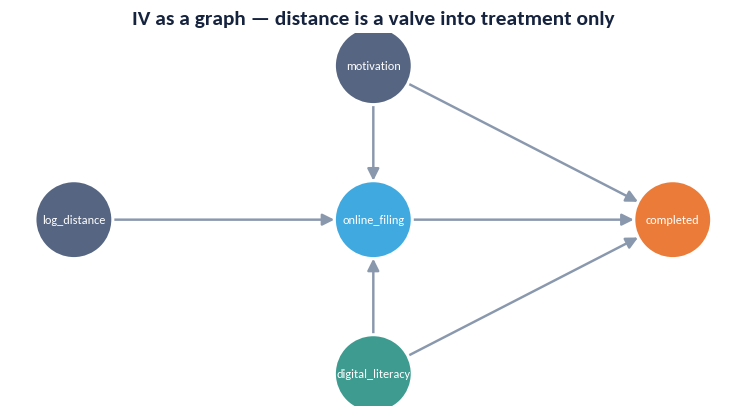

In [21]:
G_iv = nx.DiGraph([
    ("log_distance", "online_filing"),      # RELEVANCE: far from an office -> file online
    ("motivation", "online_filing"),        # unmeasured confounder ->  treatment
    ("motivation", "completed"),            # unmeasured confounder ->  outcome
    ("digital_literacy", "online_filing"),
    ("digital_literacy", "completed"),
    ("online_filing", "completed"),         # the effect of interest
])

paths = list(nx.all_simple_paths(G_iv, "log_distance", "completed"))
print("Directed paths from the instrument to the outcome:")
for p in paths:
    print("   " + " -> ".join(p))
print("\nEXCLUSION: every path runs through online_filing - distance has no direct arrow")
print("           into completed. This is an ASSUMPTION drawn as a MISSING arrow, and")
print("           it is not testable. Defend it: where you live changes how you file,")
print("           but not (we claim) whether you can complete a form once you start.")
print("INDEPENDENCE: no arrow from `motivation` into log_distance - people did not")
print("           choose where to live based on how motivated they feel about e-forms.")
print("RELEVANCE : testable. In Lab 5 the first-stage F was about 2,120, far above 10.")

def _c():
    assert G_iv is not None, "G_iv is still None"
    paths = list(nx.all_simple_paths(G_iv, "log_distance", "completed"))
    assert all("online_filing" in p for p in paths), \
        "exclusion restriction violated: distance reaches the outcome without going through filing"
check("distance satisfies the exclusion restriction in your graph", _c)

POSI = {"log_distance": (0, 0), "motivation": (1.4, 1.4), "digital_literacy": (1.4, -1.4),
        "online_filing": (1.4, 0), "completed": (2.8, 0)}
fig, ax = plt.subplots(figsize=(8.5, 4.4))
draw_dag(G_iv, ax=ax, treatment="online_filing", outcome="completed",
         adjust=("digital_literacy",), pos=POSI,
         title="IV as a graph — distance is a valve into treatment only")
plt.show()

### 3. Discussion *(5 min)*

**(a)** A colleague says *"more controls always reduce bias."* Refute it with a collider
example in two sentences.

**(b)** When is deliberately controlling for a mediator the *right* thing to do?

In [22]:
DISCUSSION = {
    "a_more_controls_always_better": (
        "No: digital_literacy and service_simplicity are independent by construction, yet "
        "'controlling for' completion - or merely analysing only completers - manufactures "
        f"a correlation of {corr_cond:+.2f} between them. Adding a control can create bias "
        "that was not there, so the question is never 'how many controls' but 'which ones "
        "does the graph say'."),
    "b_when_is_a_mediator_control_right": (
        "When the decision genuinely turns on the DIRECT effect and you say so explicitly. "
        "Example: 'if we cannot expand the support desk, does the training still help?' - "
        "that question holds support usage fixed on purpose, so blocking the mediator is "
        "correct. The discipline is to name the estimand (controlled direct effect), not to "
        "report it as 'the effect'. Mediation analysis also requires no unmeasured "
        "confounding of the MEDIATOR-outcome relationship, which is a much stronger "
        "assumption than the one the total effect needs."),
}
for k, v in DISCUSSION.items():
    print(f"\n{k}:\n  {v}")


a_more_controls_always_better:
  No: digital_literacy and service_simplicity are independent by construction, yet 'controlling for' completion - or merely analysing only completers - manufactures a correlation of -0.20 between them. Adding a control can create bias that was not there, so the question is never 'how many controls' but 'which ones does the graph say'.

b_when_is_a_mediator_control_right:
  When the decision genuinely turns on the DIRECT effect and you say so explicitly. Example: 'if we cannot expand the support desk, does the training still help?' - that question holds support usage fixed on purpose, so blocking the mediator is correct. The discipline is to name the estimand (controlled direct effect), not to report it as 'the effect'. Mediation analysis also requires no unmeasured confounding of the MEDIATOR-outcome relationship, which is a much stronger assumption than the one the total effect needs.


---

### Quiz recall (Module 6)

1. **What does an *absent* arrow assert?** → that there is no direct causal effect between
   those variables.
2. **What happens when you condition on a collider?** → a spurious association opens between
   its causes.
3. **State the backdoor criterion.** → adjust for a set that blocks all backdoor paths and
   contains no descendant of the treatment.
4. **Why not control for a mediator when estimating a total effect?** → it blocks part of the
   causal path, shrinking the effect.
5. **What are the three identification verdicts?** → identifiable by backdoor set *S*;
   identifiable by another route (frontdoor / IV); not identifiable with current data.

### Next

**Lab 7** — everything at once. One real decision, method selection, a frozen plan, an A/B
test, a reconciliation with the observational evidence, and a memo a director can act on.